In [1]:
# 动力学测试：从A到B点，10*10 * 10*10 数据分析

In [29]:
# 数据读取
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
data = np.load('../data/Exp-A2B 10000-20241226_230233/StepResponse_list.npy')
# data = np.load('../data/Exp-A2B 10000-20241223_131316/StaticState_list.npy')

ExpStructList_mat = sio.loadmat('../AtoBMatlab/ExpData.mat')

In [ ]:
# 解包Matlab

StartPoint_index = 94    # 按照实验序号
EndPoint_index = 97      # 按照实验序号

group = StartPoint_index*100 + EndPoint_index
t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
plt.plot(t_matlab, theta1_matlab)
plt.plot(t_matlab, theta2_matlab)
print(t_matlab.flatten().shape)
print(t_matlab.shape)
print(theta1_matlab.shape)
t_matlab

In [ ]:
# 解包-Mujoco大数据包
Theta1_array = np.linspace(math.pi/6, math.pi*2/3, 10)
Theta2_array = np.linspace(0, math.pi/2, 10)

data_matrix = data.reshape(100, 100, data.shape[1], data.shape[2])  # 每一行是相同的theta1，每一列是相同的theta2

# 解析坐标
# copy from Run
StartPointArray = []
for theta_1 in Theta1_array:
  for theta_2 in Theta2_array:
    StartPointArray.append([theta_1, theta_2])
StartPointArray = np.array(StartPointArray)
EndPointArray = StartPointArray

# StartPoint_index = 0    # 按照实验序号
# EndPoint_index = 2      # 按照实验序号
# t_bias = (100*StartPoint_index + EndPoint_index) * 20   # 不太准确

Pos_startPoint = StartPointArray[StartPoint_index]
Pos_endPoint = EndPointArray[EndPoint_index]

exp1data = np.array(data_matrix[StartPoint_index][EndPoint_index])
print(exp1data.shape)
plt.plot(exp1data[:, 0], (exp1data[:, 1]+math.pi/2)/math.pi*180, label='theta1')
plt.plot(exp1data[:, 0], exp1data[:, 2]/math.pi*180, label="theta2")
plt.title(f"Move from {Pos_startPoint/math.pi*180} to {Pos_endPoint/math.pi*180} deg")
plt.legend()
plt.show()

exp1data[:, 0]

In [ ]:
# 对比

def step_response_compare(t_array_matlab, theta1_array_matlab, theta2_array_matlab, t_array_mujoco, theta1_array_mujoco, theta2_array_mujoco, if_plot=True):
    # 时间并没有对齐
    if if_plot:
        plt.plot(t_array_matlab, label="TheoTime")
        plt.plot(t_array_mujoco, 'r', label="SimTime")
        plt.legend()
        plt.show()

        plt.plot(t_array_mujoco, theta1_array_mujoco, label="theta1_sim")
        plt.plot(t_array_mujoco, theta2_array_mujoco, label="theta2_sim")
        plt.plot(t_array_matlab, theta1_array_matlab, label="theta1_theo")
        plt.plot(t_array_matlab, theta2_array_matlab, label="theta2_theo")
        plt.legend()
        plt.xlabel("time/s")
        plt.ylabel("angle/rad")
        plt.xlim([0, 10])
        plt.ylim([0, 5])


    # cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
    t_intervel = np.linspace(0, 10, 1000)
    theta1_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta1_array_mujoco)
    theta2_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta2_array_mujoco)
    theta1_theo_intervel = np.interp(t_intervel, t_array_matlab, theta1_array_matlab)
    theta2_theo_intervel = np.interp(t_intervel, t_array_matlab, theta2_array_matlab)

    mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_theo_intervel))
    mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_theo_intervel))
    maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_theo_intervel))
    maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_theo_intervel))

    if if_plot:
        plt.text(2, 1.4, f"MSE_theta_1[0-10s]={round(mse_theta1, 6)}rad^2")
        plt.text(2, 1.3, f"MaxError_theta_1[0-10s]={round(maxerror_theta1, 6)}rad")
        plt.text(2, 0.6, f"MSE_theta_2[0-10s]={round(mse_theta2, 6)}rad^2")
        plt.text(2, 0.5, f"MaxError_theta_2[0-10s]={round(maxerror_theta2, 6)}rad")

        plt.show()
    
    return mse_theta1, mse_theta2, maxerror_theta1, maxerror_theta2
t_bias = exp1data[0, 0]
step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2])

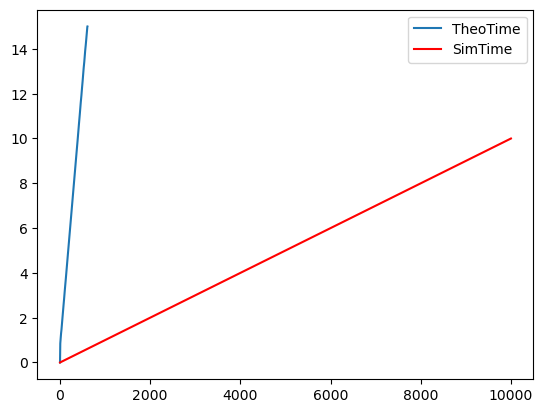

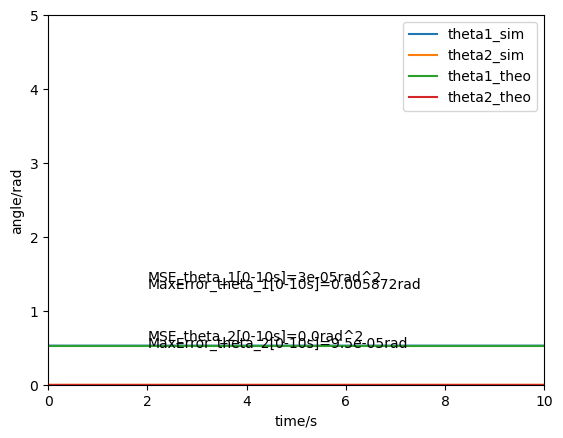

0.4552618699757826
0.7021591217693347


In [53]:
def single_exp(StartPoint_index=0, EndPoint_index=0):
    i = StartPoint_index
    j = EndPoint_index
    group = i*100 + j
    t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
    # Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
    theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
    theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
    exp1data = np.array(data_matrix[i][j])
    t_bias = exp1data[0, 0]

    # check ang range
    if np.max(exp1data[:, 1]) > math.pi or np.min(exp1data[:, 1]) < -math.pi:
        print(f"theta1_mujoco Error in {i}, {j}")
    if np.max(exp1data[:, 2]) > math.pi or np.min(exp1data[:, 2]) < -math.pi:
        print(f"theta2_mujoco Error in {i}, {j}")

    if np.max(theta1_matlab) > math.pi or np.min(theta1_matlab) < -math.pi:
        print(f"theta1_matlab Error in {i}, {j}")
    if np.max(theta2_matlab) > math.pi or np.min(theta2_matlab) < -math.pi:
        print(f"theta2_matlab Error in {i}, {j}")


    error = step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2], True)
    # if error[0] > 2:
    #     print(f"Error in {i}, {j}")
    # print(error)
    return error

single_exp()
print(np.min(exp1data[:, 1]))
print(np.min(exp1data[:, 2]))


In [62]:
def group_step_exps():
    error_list = []
    for i in tqdm(range(100)):
        for j in range(100):
            group = i*100 + j
            t_matlab = ExpStructList_mat['ExpData'][0][group][0][:].flatten()
            # Xt_matlab = ExpStructList_mat['ExpData'][0][group][1][:]
            theta1_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 0]
            theta2_matlab = ExpStructList_mat['ExpData'][0][group][1][:, 1]
            exp1data = np.array(data_matrix[i][j])
            t_bias = exp1data[0, 0]
                # check ang range
            valid = True
            if np.max(exp1data[:, 1]+math.pi/2) > math.pi*2/3 or np.min(exp1data[:, 1]+math.pi/2) < -0.02:
                print(f"theta1_mujoco Error in {i}, {j}, {np.max(exp1data[:, 1]+math.pi/2)}, {np.min(exp1data[:, 1]+math.pi/2)}")
                valid = False
            if np.max(exp1data[:, 2]) > math.pi/2 or np.min(exp1data[:, 2]) < -0.02:
                print(f"theta2_mujoco Error in {i}, {j}")
                valid = False
            if np.max(theta1_matlab) > math.pi*2/3 or np.min(theta1_matlab) < -0.02:
                print(f"theta1_matlab Error in {i}, {j}")
                valid = False
            if np.max(theta2_matlab) > math.pi/2 or np.min(theta2_matlab) < -0.02:
                print(f"theta2_matlab Error in {i}, {j}")
                valid = False
            if valid:
                error = step_response_compare(t_matlab.flatten(), theta1_matlab, theta2_matlab, exp1data[:, 0]-t_bias, (exp1data[:, 1]+math.pi/2), exp1data[:, 2], False)
                # print(error)
                if error[0] > 2:
                    print(f"Error in {i}, {j}")
                error_list.append(error)
    return np.array(error_list)

error_list = group_step_exps()


  1%|          | 1/100 [00:00<00:19,  5.03it/s]

theta2_mujoco Error in 0, 8
theta2_matlab Error in 0, 8
theta2_mujoco Error in 0, 9
theta2_matlab Error in 0, 9
theta2_matlab Error in 0, 10
theta2_mujoco Error in 0, 18
theta2_matlab Error in 0, 18
theta2_mujoco Error in 0, 19
theta2_matlab Error in 0, 19
theta2_mujoco Error in 0, 20
theta2_matlab Error in 0, 20
theta2_matlab Error in 0, 21
theta2_mujoco Error in 0, 27
theta2_matlab Error in 0, 27
theta2_mujoco Error in 0, 28
theta2_matlab Error in 0, 28
theta2_mujoco Error in 0, 29
theta2_matlab Error in 0, 29
theta2_mujoco Error in 0, 30
theta2_matlab Error in 0, 30
theta2_mujoco Error in 0, 31
theta2_matlab Error in 0, 31
theta2_mujoco Error in 0, 36
theta2_mujoco Error in 0, 37
theta2_matlab Error in 0, 37
theta2_mujoco Error in 0, 38
theta2_matlab Error in 0, 38
theta2_mujoco Error in 0, 39
theta2_matlab Error in 0, 39
theta2_mujoco Error in 0, 40
theta2_matlab Error in 0, 40
theta2_mujoco Error in 0, 41
theta2_matlab Error in 0, 41
theta2_mujoco Error in 0, 42
theta2_matlab Erro

  2%|▏         | 2/100 [00:00<00:19,  5.13it/s]

theta2_mujoco Error in 1, 18
theta2_matlab Error in 1, 18
theta2_mujoco Error in 1, 19
theta2_matlab Error in 1, 19
theta2_mujoco Error in 1, 20
theta2_matlab Error in 1, 20
theta2_mujoco Error in 1, 27
theta2_matlab Error in 1, 27
theta2_mujoco Error in 1, 28
theta2_matlab Error in 1, 28
theta2_mujoco Error in 1, 29
theta2_matlab Error in 1, 29
theta2_mujoco Error in 1, 30
theta2_matlab Error in 1, 30
theta2_mujoco Error in 1, 31
theta2_matlab Error in 1, 31
theta2_mujoco Error in 1, 37
theta2_matlab Error in 1, 37
theta2_mujoco Error in 1, 38
theta2_matlab Error in 1, 38
theta2_mujoco Error in 1, 39
theta2_matlab Error in 1, 39
theta2_mujoco Error in 1, 40
theta2_matlab Error in 1, 40
theta2_mujoco Error in 1, 41
theta2_matlab Error in 1, 41
theta2_mujoco Error in 1, 42
theta2_matlab Error in 1, 42
theta2_mujoco Error in 1, 46
theta2_matlab Error in 1, 46
theta2_mujoco Error in 1, 47
theta2_matlab Error in 1, 47
theta2_mujoco Error in 1, 48
theta2_matlab Error in 1, 48
theta2_mujoco 

  3%|▎         | 3/100 [00:00<00:18,  5.18it/s]

...

theta1_mujoco Error in 84, 6, 1.91677478015868, -0.10565307393693146
theta1_matlab Error in 84, 6
theta1_mujoco Error in 84, 7, 1.9162085222417269, -0.10508010811617474
theta1_matlab Error in 84, 7
theta1_mujoco Error in 84, 8, 1.9162062633252415, -0.10505894071996646
theta2_mujoco Error in 84, 8
theta1_matlab Error in 84, 8
theta2_matlab Error in 84, 8
theta1_mujoco Error in 84, 9, 1.9162031049578276, -0.09377855276628133
theta2_mujoco Error in 84, 9
theta1_matlab Error in 84, 9
theta2_matlab Error in 84, 9
theta1_mujoco Error in 84, 10, 2.0186272914574914, -0.09038526989389473
theta2_mujoco Error in 84, 10
theta1_matlab Error in 84, 10
theta2_matlab Error in 84, 10
theta1_mujoco Error in 84, 11, 2.009089597058802, -0.08589129228758718
theta2_mujoco Error in 84, 11
theta1_matlab Error in 84, 11
theta2_matlab Error in 84, 11
theta1_mujoco Error in 84, 12, 1.9954393919804956, -0.08981674055847622
theta2_mujoco Error in 84, 12
theta1_matlab Error in 84, 12
theta2_matlab Error in 84, 12
t

 95%|█████████▌| 95/100 [00:07<00:00, 35.83it/s]

theta1_matlab Error in 91, 25
theta1_mujoco Error in 91, 26, 2.089015148639742, -0.05477804092912919
theta1_matlab Error in 91, 26
theta2_matlab Error in 91, 26
theta1_mujoco Error in 91, 27, 2.089013305830708, -0.04546246323712455
theta2_mujoco Error in 91, 27
theta1_matlab Error in 91, 27
theta2_matlab Error in 91, 27
theta2_mujoco Error in 91, 28
theta1_matlab Error in 91, 28
theta2_matlab Error in 91, 28
theta2_mujoco Error in 91, 29
theta1_matlab Error in 91, 29
theta2_matlab Error in 91, 29
theta1_mujoco Error in 91, 30, 2.1184234282444745, -0.053727001597546176
theta2_mujoco Error in 91, 30
theta1_matlab Error in 91, 30
theta2_matlab Error in 91, 30
theta1_mujoco Error in 91, 31, 2.1128203681174997, -0.04967886723140458
theta2_mujoco Error in 91, 31
theta1_matlab Error in 91, 31
theta2_matlab Error in 91, 31
theta1_mujoco Error in 91, 32, 2.1074828281552938, -0.04082667197059098
theta2_mujoco Error in 91, 32
theta1_matlab Error in 91, 32
theta2_matlab Error in 91, 32
theta1_mujo

100%|██████████| 100/100 [00:07<00:00, 12.67it/s]

theta1_mujoco Error in 97, 54, 2.165581265706044, 0.7397456957188072
theta2_mujoco Error in 97, 54
theta1_matlab Error in 97, 54
theta2_matlab Error in 97, 54
theta1_mujoco Error in 97, 55, 2.1208365806222576, 0.7891064980614395
theta1_matlab Error in 97, 55
theta1_matlab Error in 97, 56
theta2_matlab Error in 97, 56
theta2_mujoco Error in 97, 57
theta2_matlab Error in 97, 57
theta2_mujoco Error in 97, 58
theta2_matlab Error in 97, 58
theta2_mujoco Error in 97, 59
theta2_matlab Error in 97, 59
theta1_mujoco Error in 97, 60, 2.262707807783536, 0.8964103879561262
theta2_mujoco Error in 97, 60
theta1_matlab Error in 97, 60
theta2_matlab Error in 97, 60
theta1_mujoco Error in 97, 61, 2.249592359611616, 0.9380973316882286
theta2_mujoco Error in 97, 61
theta1_matlab Error in 97, 61
theta2_matlab Error in 97, 61
theta1_mujoco Error in 97, 62, 2.231096930878346, 0.9900077049636937
theta2_mujoco Error in 97, 62
theta1_matlab Error in 97, 62
theta2_matlab Error in 97, 62
theta1_mujoco Error in 9

In [64]:
# 计算最大误差
print(error_list.shape) # 30% 的模型满足要求
max_mse_theta1 = np.max(error_list[:, 0])
max_mse_theta2 = np.max(error_list[:, 1])
max_maxerror_theta1 = np.max(error_list[:, 2])
max_maxerror_theta2 = np.max(error_list[:, 3])

print(f"max_mse_theta1={max_mse_theta1}")
print(f"max_mse_theta2={max_mse_theta2}")
print(f"max_maxerror_theta1={max_maxerror_theta1}")
print(f"max_maxerror_theta2={max_maxerror_theta2}")
error_list[:, 0]


(3297, 4)
max_mse_theta1=0.0004881864707780593
max_mse_theta2=0.00024210418788155646
max_maxerror_theta1=0.10085720193373415
max_maxerror_theta2=0.12699038263777096


array([2.95700540e-05, 3.52319974e-05, 4.04313619e-05, ...,
       1.71632812e-05, 1.43564198e-05, 1.19795187e-05])

()